In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:03<00:00, 49.2MB/s]


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [6]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [7]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

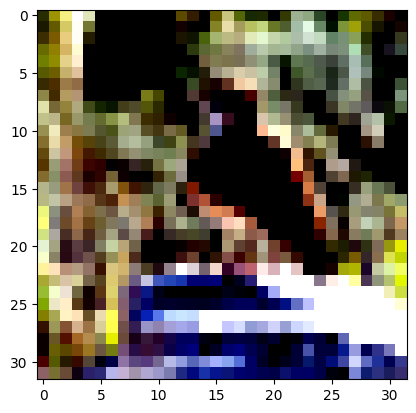

In [8]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [9]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [10]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [11]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [12]:
class Trainer:
    def __init__(self, config, model_class=BasicCNN, transform=None, model_name=None):
        self.config = config
        self.transform = transform
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = model_class().to(self.device)
        self.model_name = model_name or model_class.__name__

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': [],
            'test_loss': [], 'test_acc': []
        }

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(
            list(range(len(train_dataset_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.eval_step(self.val_loader)
            test_loss, test_acc = self.eval_step(self.test_loader)

            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['test_loss'].append(test_loss)
            self.history['test_acc'].append(test_acc)

            print(
                f"Epoch {epoch + 1}/{self.config['num_epochs']} | "
                f"train_loss={train_loss:.4f}, train_acc={train_acc:.2f}% | "
                f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}% | "
                f"test_loss={test_loss:.4f}, test_acc={test_acc:.2f}%"
            )

        return self.history

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def eval_step(self, loader):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        with torch.no_grad():
            for images, labels in tqdm(loader):
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.loss_function(outputs, labels)

                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total_samples += labels.size(0)

        total_loss = total_loss / len(loader)
        accuracy = correct / total_samples * 100

        return total_loss, accuracy



In [13]:
trainer = Trainer(config, transform=transform)

In [14]:
trainer.run()

100%|██████████| 79/79 [00:02<00:00, 31.20it/s]


Epoch 1/10 | train_loss=1.7158, train_acc=36.60% | val_loss=1.5326, val_acc=44.71% | test_loss=1.5145, test_acc=44.70%


100%|██████████| 79/79 [00:02<00:00, 31.52it/s]


Epoch 2/10 | train_loss=1.4171, train_acc=48.40% | val_loss=1.3824, val_acc=49.84% | test_loss=1.3973, test_acc=48.98%


100%|██████████| 79/79 [00:02<00:00, 26.57it/s]


...

100%|██████████| 79/79 [00:02<00:00, 31.95it/s]


Epoch 9/10 | train_loss=1.0064, train_acc=63.73% | val_loss=1.1554, val_acc=59.62% | test_loss=1.1801, test_acc=58.67%


100%|██████████| 79/79 [00:02<00:00, 32.58it/s]

Epoch 10/10 | train_loss=0.9912, train_acc=64.38% | val_loss=1.1583, val_acc=59.51% | test_loss=1.1823, test_acc=58.85%


{'train_loss': [1.7157868702952472,
  1.4171477023024148,
  1.354893183936707,
  1.2953971285408679,
  1.2559986963820533,
  1.0984905933419737,
  1.048979188306644,
  1.0248520202910938,
  1.0064202173830221,
  0.9911732700305244],
 'train_acc': [36.5975,
  48.402499999999996,
  51.10249999999999,
  53.50749999999999,
  54.98,
  60.5175,
  62.35000000000001,
  63.235,
  63.7325,
  64.375],
 'val_loss': [1.5325503877446622,
  1.3824092791050295,
  1.378912533385844,
  1.2872525498836855,
  1.3375781336917152,
  1.1819847150693965,
  1.1870724143861215,
  1.1756042740013026,
  1.1554385340666469,
  1.1583194559133505],
 'val_acc': [44.71,
  49.84,
  50.44,
  53.44,
  50.8,
  58.050000000000004,
  58.940000000000005,
  58.5,
  59.62,
  59.51],
 'test_loss': [1.5145414750787276,
  1.3972952018810223,
  1.3727798808979084,
  1.3046462882923175,
  1.3506525181516815,
  1.2040580677080759,
  1.210708655134032,
  1.1938874382006972,
  1.1800549558446378,
  1.1822601564322845],
 'test_acc': [4

# ResNet-18

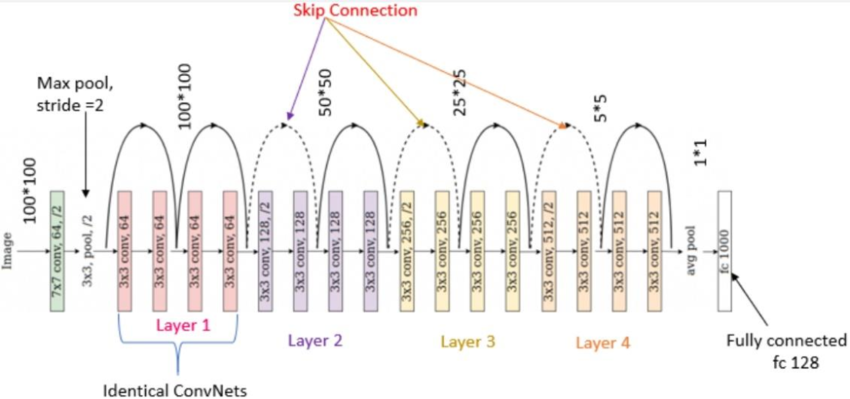

In [15]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = F.relu(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = [ResNetBlock(self.in_channels, out_channels, stride=stride, downsample=downsample)]
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.max_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x



$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

100%|██████████| 79/79 [00:04<00:00, 19.24it/s]


Epoch 1/10 | train_loss=1.7164, train_acc=36.53% | val_loss=1.5056, val_acc=44.99% | test_loss=1.5094, test_acc=44.45%


100%|██████████| 79/79 [00:02<00:00, 32.70it/s]


Epoch 2/10 | train_loss=1.4170, train_acc=48.78% | val_loss=1.3378, val_acc=51.54% | test_loss=1.3494, test_acc=50.99%


100%|██████████| 79/79 [00:02<00:00, 33.17it/s]


...

Epoch 8/10 | train_loss=0.4066, train_acc=85.89% | val_loss=0.7762, val_acc=75.57% | test_loss=0.8148, test_acc=74.38%


100%|██████████| 79/79 [00:03<00:00, 21.43it/s]


Epoch 9/10 | train_loss=0.3391, train_acc=88.36% | val_loss=0.8412, val_acc=74.55% | test_loss=0.8806, test_acc=73.70%


100%|██████████| 79/79 [00:03<00:00, 23.19it/s]


Epoch 10/10 | train_loss=0.2675, train_acc=90.82% | val_loss=0.8845, val_acc=74.76% | test_loss=0.9346, test_acc=74.08%


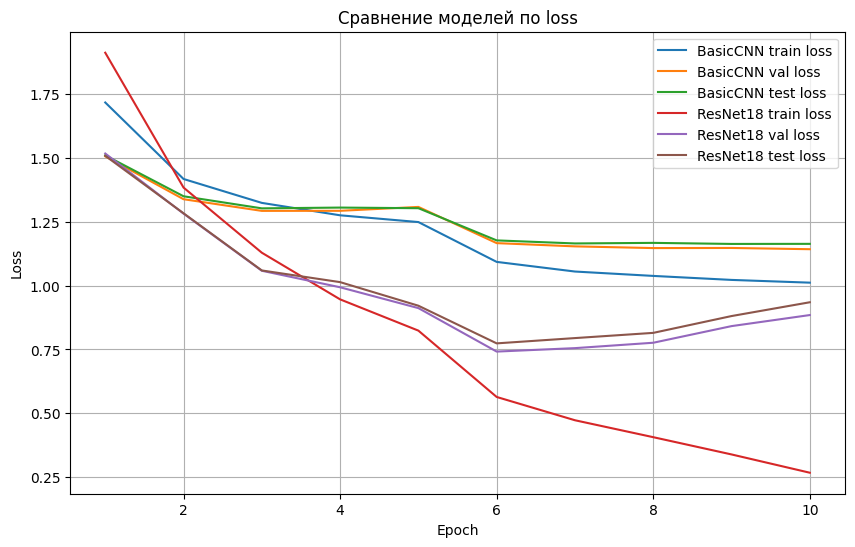

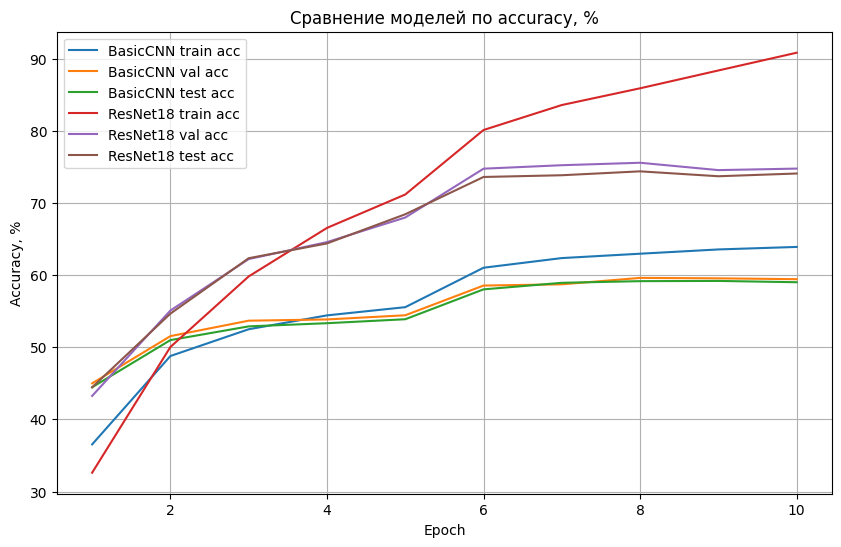

BasicCNN final test accuracy: 59.01
ResNet18 final test accuracy: 74.08


In [16]:
basic_trainer = Trainer(config, model_class=BasicCNN, transform=transform, model_name='BasicCNN')
basic_history = basic_trainer.run()

resnet_trainer = Trainer(config, model_class=ResNet18, transform=transform, model_name='ResNet18')
resnet_history = resnet_trainer.run()


def plot_metric(metric_name, ylabel):
    epochs = range(1, config['num_epochs'] + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, basic_history[f'train_{metric_name}'], label=f'BasicCNN train {metric_name}')
    plt.plot(epochs, basic_history[f'val_{metric_name}'], label=f'BasicCNN val {metric_name}')
    plt.plot(epochs, basic_history[f'test_{metric_name}'], label=f'BasicCNN test {metric_name}')
    plt.plot(epochs, resnet_history[f'train_{metric_name}'], label=f'ResNet18 train {metric_name}')
    plt.plot(epochs, resnet_history[f'val_{metric_name}'], label=f'ResNet18 val {metric_name}')
    plt.plot(epochs, resnet_history[f'test_{metric_name}'], label=f'ResNet18 test {metric_name}')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(f'Сравнение моделей по {ylabel.lower()}')
    plt.grid(True)
    plt.legend()
    plt.show()


plot_metric('loss', 'Loss')
plot_metric('acc', 'Accuracy, %')

print('BasicCNN final test accuracy:', round(basic_history['test_acc'][-1], 2))
print('ResNet18 final test accuracy:', round(resnet_history['test_acc'][-1], 2))



ResNet18 показала себя лучше простой CNN: итоговая точность на тесте составила 74.08% против 59.01%. По графикам видно, что ResNet18 быстрее обучается и достигает более высокого качества, хотя на последних эпохах появляются небольшие признаки переобучения.